<a href="https://colab.research.google.com/github/gmauricio-toledo/tda-gdl/blob/main/07-UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UMAP: Uniform Manifold Approximation and Projection

* ArXiv: [https://arxiv.org/abs/1802.03426](https://arxiv.org/abs/1802.03426)
* GitHub: [https://github.com/lmcinnes/umap](https://github.com/lmcinnes/umap)
* Tutorial: [https://umap-learn.readthedocs.io/en/latest/#](https://umap-learn.readthedocs.io/en/latest/#)


Es un método de **reducción de dimensionalidad** que:

- Se fundamenta en conceptos de geometría diferencial y topología algebraica
- **Preserva "la" estructura local y global** de los datos
- En general, es más rápido que t-SNE
- Provee "buenas" visualizaciones

Usos:

- **Visualización**: Datos de alta dimensión $\to$ 2D/3D interpretables
- **Preprocessing**: Para clustering o clasificación
- **Exploración**: Descubrir patrones "ocultos" en datos
- **Interpretabilidad**: Entender "la" estructura de datos complejos

In [ ]:
!pip install umap-learn seaborn

# MNIST

Se muestra una manera de aplicar UMAP al dataset MNIST:

1. **Preparación**: Carga de datos.
2. **Aplicación**: Configuración y ejecución de UMAP.
3. **Visualización**: Análisis de los resultados en 2D.
4. **Evaluación**: Métricas de calidad del embedding.

NOTAS:
- UMAP preserva tanto estructura local como globlal.
- Los dígitos forman clusters naturales "bien" separados.
- Los parámetros `n_neighbors` y `min_dist` afectan la estructura final.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
import time

`fetch_openml` permite descargar datasets directamente desde OpenML (Open Machine Learning), el cual es un repositorio público de datasets para machine learning.

¿Por qué usar `fetch_openml`?
- Acceso directo a datasets estándar sin necesidad de descargas manuales.
- Garantiza consistencia en formato y versiones.
- Incluye metadatos del dataset automáticamente.

## Cargar MNIST:

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, Y = mnist.data, mnist.target.astype(int)

In [ ]:
print(f"Datos: {X.shape}")
print(f"Etiquetas: {Y.shape}")
print(f"Rango de valores: {X.min()} - {X.max()}")
print(f"Clases: {np.unique(Y)}")

Datos: (70000, 784)
Etiquetas: (70000,)
Rango de valores: 0 - 255
Clases: [0 1 2 3 4 5 6 7 8 9]


* **Estructura de Primeros Datos:**

In [ ]:
print("Primeras 5 etiquetas:", Y[:5])
print("Forma de primera imagen:", X[0].reshape(28, 28).shape)
print("Estadísticas de primera imagen:")
print(f"Min: {X[0].min()}")
print(f"Max: {X[0].max()}")
print(f"Media: {X[0].mean():.2f}")
print(f"Std: {X[0].std():.2f}")

Primeras 5 etiquetas: [5 0 4 1 9]
Forma de primera imagen: (28, 28)
Estadísticas de primera imagen:
Min: 0
Max: 255
Media: 35.11
Std: 79.65


---

**Parámetros:**

`'mnist_784'`
- Identificador único del dataset MNIST en OpenML
- El "784" hace referencia a las dimensiones: 28×28 = 784 píxeles por imagen

`version=1`
- Especifica la versión del dataset a descargar
- Versión 1 es la versión estándar

`as_frame=False`
- Formato de salida: NumPy arrays en lugar de pandas DataFrames
- `False`: Retorna carrays de NumPy (recomendable para ML)
- `True`: Retornaría pandas DataFrame (recomendable para análisis exploratorio)

---

**Separación de Datos y Etiquetas:**

Estructura del objeto `mnist`:
- `mnist.data`: Matriz de características (imágenes)
- `mnist.target`: Vector de etiquetas (dígitos)
- `mnist.DESCR`: Descripción del dataset
- `mnist.feature_names`: Nombres de las características

`X = mnist.data`
- X: Matriz de características (convención en ML)
- Forma: (70000, 784)
  - 70,000 imágenes
  - 784 características por imagen (28×28 píxeles)
- Tipo de datos: float64 por defecto
- Valores: Intensidad de píxeles (0-255)

#### `y = mnist.target.astype(int)`
- Y: Vector de etiquetas objetivo
- Forma: (70000,)
- Conversión .astype(int):
  - Las etiquetas vienen como strings ('0', '1', '2', ...)
  - Se convierten a enteros (0, 1, 2, ...) para procesamiento
  - Más eficiente para algoritmos de ML

---

**Inspección de Dimensiones**

Interpretación de `X.shape`:
  - (70000, 784) significa: 70,000 muestras (imágenes) y 784 características por muestra
  - Cada imagen 28x28 se ha "aplanado" en un vector unidimensional

Interpretación de `Y.shape`:
- (70000, ) significa: 70,000 etiquetas, una etiqueta por cada imagen. Lo que resulta en un vector unidimensional

¿Por qué 70,000 muestras?
- MNIST completo: 60,000 entrenamiento + 10,000 prueba
- `fetch_openml` descarga el dataset completo por defecto
- La separación train/test debe hacerse manualmente si se requiere

---

**Análisis del Rango de Valores (`{X.min()}` - `{X.max()}`)**

¿Qué información proporciona?
- Valores esperados: 0 - 255
- 0: píxel completamente negro (fondo)
- 255: píxel completamente blanco (tinta)
- Valores intermedios: Diferentes tonos de gris

En general, UMAP funciona mejor con datos normalizados. El rango 0-255 puede causar que características con valores altos dominen. De ser necesario, se recomienda preprocesamiento

---

**Verificación de Clases (`np.unique(Y)`)**

- Salida esperada: `[0 1 2 3 4 5 6 7 8 9]`
- 10 clases: dígitos del 0 al 9
- Balanceado: aproximadamente igual número de muestras por clase

---

**Resumen:**

- **X**: (70000, 784) - Imágenes "aplanadas"
- **Y**: (70000,) - Etiquetas de dígitos (0-9)
- **Formato**: Arrays de NumPy
- **Rango**: 0-255 (se sugiere normalización)

___

## Visualizar Imágenes de MNIST:

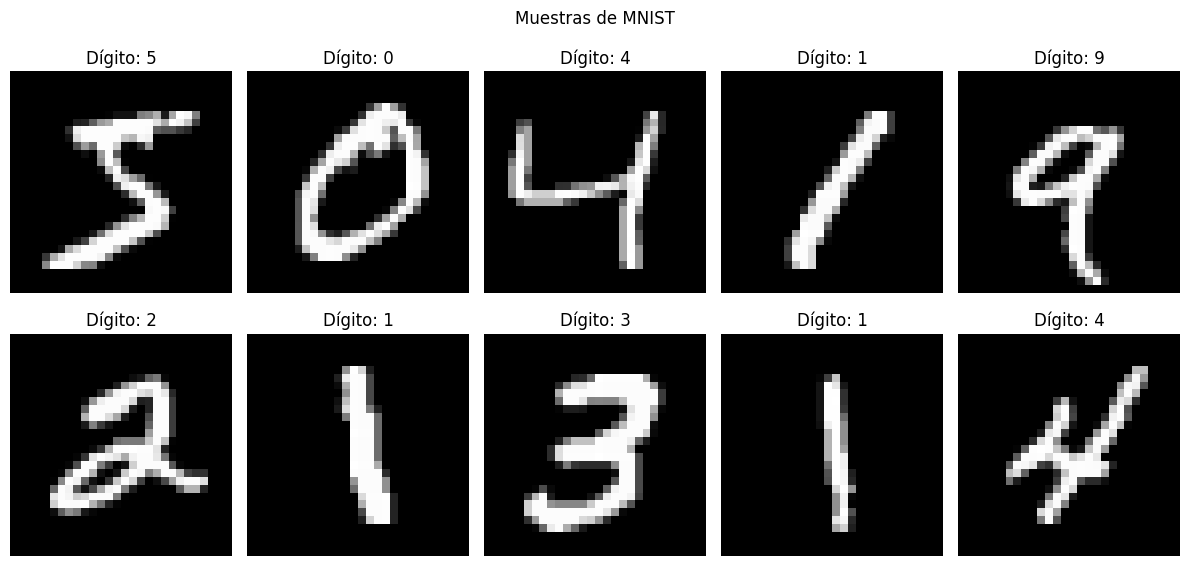

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Muestras de MNIST', fontsize=12)

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f'Dígito: {Y[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

___

**Configuración de la Estructura de Visualización:**

`plt.subplots(2, 5, figsize=(12, 6))`
- `2, 5`: Crea una cuadrícula de *2 filas x 5 columnas* = 10 subplots
- `figsize=(12, 6)`: Tamaño de la figura completa en pulgadas
  - 12 pulgadas de ancho (suficiente espacio para 5 imágenes por fila)
  - 6 pulgadas de alto (altura para 2 filas)

Objetos devueltos:
- `fig`: Objeto Figure (contenedor principal)
- `axes`: Array 2D de objetos Axes (subplots individuales)
  - Forma: `axes.shape = (2, 5)`
  - Cada `axes[i, j]` es un subplot individual

---

**Configuración del Título Principal:**

`fig.suptitle()`
- Función: Añade título principal a toda la figura
- Posición: Centrado en la parte superior
- Diferencia con `plt.title()`:
  - `suptitle()`: Título de toda la figura
  - `title()`: Título de un subplot individual
- `fontsize=16`: Tamaño de fuente grande para visibilidad

---

**Iteración a través de los Subplots. Desglose de la Iteración:**

`axes.flat`
- Iterador que "aplana" el array 2D de axes
- Conversión: `axes[2,5]` $\to$ secuencia lineal de 10 elementos
- Orden: Fila por fila (row-major order)

  `axes[0,0]` $\to$ `axes[0,1]` $\to$ ... $\to$ `axes[0,4]` $\to$
  `axes[1,0]` $\to$ `axes[1,1]` $\to$ ... $\to$ `axes[1,4]`

`enumerate()`
- Añade un contador automático a la iteración
- Retorna: Tuplas `(índice, valor)`
- Ventaja: Acceso simultáneo al índice y al objeto axes

---

**Transformación y Visualización de Imágenes. Análisis Detallado de Cada Componente:**

`X[i]`
- i-ésima imagen del dataset
- `(784,)` - Vector unidimensional
- Valores de píxeles 0-255

`.reshape(28, 28)`
- Redimensiona el vector 1D a matriz 2D
- Transformación: `(784,)` → `(28, 28)`
- Orden: Row-major (fila por fila)
- Validación matemática: 784 = 28 x 28

`cmap='gray'`
- Escala de grises
- Mapeo:
  - Valor 0 $\to$ Negro (fondo)
  - Valor 255 $\to$ Blanco (tinta)
  - Valores intermedios $\to$ Tonos de gris
- ¿Por qué 'gray'?: MNIST son imágenes en escala de grises originalmente

---

**Configuración de Títulos Individuales. Componentes:**

`Y[i]`
- Etiqueta correspondiente a la i-ésima imagen
- Valor: Entero 0-9 (clase del dígito)
- Correspondencia: `X[i]` (imagen) $\iff$ `Y[i]` (etiqueta)

`f'Dígito: {y[i]}'`
- f-string: Formato moderno de strings en Python
- Resultado: "Dígito: 0", "Dígito: 1",...

`ax.set_title()`
- Establece un título para cada subplot individual
- Posición: Arriba del subplot
- Diferencia con `suptitle()`: Específico para cada imagen

---

**Paso 6: Limpieza de Ejes.**

¿Por qué eliminar los ejes? No son informativos, interfieren con la imagen, los labels ocupan espacio innecesario.

`ax.axis('off')`
- Elimina: Ticks, labels, y líneas de los ejes
- Conserva: La imagen y el título
- Resultado: Visualización más limpia y enfocada

---

**Optimización del Layout:**

¿Qué hace `tight_layout()`? Espacios óptimos entre subplots. Títulos y labels no se superponen. Máximo uso del área disponible

---

**Renderizado Final:**

`plt.show()`

1. Compilación: Matplotlib procesa todos los comandos
2. Renderizado: Genera la imagen final
3. Visualización: Muestra en pantalla (Jupyter/Colab)
___

**Resumen:**

- Datos visualizados y comprendidos
- Estructura de imágenes confirmada
- Listo para preprocesamiento y análisis con UMAP

___

## Preprocesamiento de Datos:

In [ ]:
n_samples = 10000  # Puedes usar menos muestras para un procesamiento más rápido
np.random.seed(42)
indices = np.random.choice(len(X), n_samples, replace=False)
X_subset = X[indices]
Y_subset = Y[indices]

print(f"Usando {n_samples} muestras para el análisis")

#Normalización de datos (recomendado para UMAP)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_subset)  #OJO: cambiar variable `X_subset` por `X_scaled`en todas las celdas!
#print("Datos normalizados correctamente")

Usando 10000 muestras para el análisis


___


**Razones para la Selección de Subconjunto de Datos (`n_samples`):**

- Consideraciones Computacionales
  - Dataset completo: 70,000 imágenes
  - Memoria RAM: ~210 MB para datos originales + embeddings
  - Tiempo de procesamiento: UMAP puede tomar 5-30 minutos en dataset completo
  - Recursos limitados: Google Colab tiene limitaciones de tiempo y memoria

- Desarrollo y Prototipado
  - Iteración rápida: Probar diferentes parámetros más eficientemente
  - Debugging: Detectar de manera "más fácil" problemas con menos datos
  - Experimentación: Validar el "pipeline" antes del procesamiento completo

- Consideraciones Pedagógicas
  - Demostración: Resultados visibles en tiempo razonable
  - Comprensión: Enfocarse en conceptos sin esperar largos procesamientos

- ¿Cuándo usar el dataset completo?
  - Análisis final y publicación
  - Cuando se requiere máxima precisión
  - Con recursos computacionales suficientes

---

**Generación de Índices Aleatorios:**

`np.random.choice()`
- Selección aleatoria de elementos
- Tipo: Muestreo estadístico controlado

`len(X)` (población)
- Valor: 70,000 (tamaño total del dataset)
- Significado: Rango de índices posibles [0, 69999]
- Tipo: Entero que define el espacio de muestreo

`n_samples` (tamaño de muestra)
- Valor: 70,000 (número de muestras deseadas)
- Proporción: ~$x$% del dataset original
- Balance: Suficiente para representatividad, manejable computacionalmente

`replace=False` (sin reemplazo)
- Cada muestra puede ser seleccionada solo una vez
- Resultado: Sin duplicados en la selección
- Alternativa: `replace=True` permitiría duplicados
- Importancia: Mantiene independencia estadística

En su caso, ¿por qué un muestreo aleatorio?
1. Representatividad: Preserva la distribución original de clases
2. Imparcialidad: Evita sesgos de selección
3. Generalización: Resultados aplicables al dataset completo

---

**Extracción de Subconjunto:**

`X[indices]`
- Tipo de operación: Indexación avanzada de NumPy (fancy indexing)
- Entrada: Array de índices `[1023, 45678, 234, ...]`
- Salida: Subarray con filas seleccionadas
- Transformación (ejemplo con n_samples=10000): `(70000, 784)` $\to$ `(10000, 784)`

`Y[indices]`
- Operación paralela: Mismos índices para mantener correspondencia
- Transformación (ejemplo con n_samples=10000): `(70000,)` → `(10000,)`
- Correspondencia: `X_subset[i]` $\iff$ `y_subset[i]`, para cada $i$.

---

**Escalador:**

¿Qué es StandardScaler? Matemáticamente, es la transformación dada por
$$
\text{X_scaled} = \frac{(X - \mu)}{\sigma},
$$
donde $\mu$ es la media de cada característica y $\sigma$ es la desviación estándar de la misma. Como resultado de la transformación se tiene:
- Media: Cero para todas las características
- Desviación estándar: 1 para todas las características
- Distribución: Mantiene la forma original, solo reescala

---

**¿Por qué Normalización para UMAP?**

Primero, algunas cuestiones que se pueden presentar sin normalización:

- Dominancia de características con valores grandes:
```python
# Ejemplo conceptual
pixel_centro = 200    # Píxel con tinta (valor alto)
pixel_esquina = 5     # Píxel de fondo (valor bajo)

# Distancia euclidiana sin normalización
dist_raw = sqrt((200-180)² + (5-3)²) = sqrt(400 + 4) = 20.1

# El píxel del centro domina el cálculo de distancia
```

- Sesgo en el cálculo de distancias:
  - UMAP usa distancias para construir el grafo de vecindarios
  - Píxeles centrales: Tienden a tener valores más altos (presencia de tinta)
  - Píxeles de borde: Generalmente son fondo (valores bajos)
  - Resultado: El algoritmo puede ignorar variaciones sutiles importantes

- Convergencia lenta:
  - UMAP usa optimización gradient descent
  - Escalas diferentes: Diferentes características requieren diferentes tasas de aprendizaje
  - Convergencia: Más lenta y menos estable sin normalización

**"Beneficios" de la normalización:**

- Equidad entre características:
  - Todas las características contribuyen igualmente
  - Variaciones sutiles se preservan
  - Mejor captura de patrones complejos

- Mejor performance del algoritmo:
  - Convergencia más rápida
  - Resultados más estables
  - Menor sensibilidad a hiperparámetros

- Interpretabilidad mejorada:
  - Distancias más significativas
  - Estructuras de cluster más claras

---

**Desglose del proceso `fit_transform`:**

Fase 1: Fit/Ajuste (`scaler.fit(X_subset)`)

- Cálculo de medias por característica:
   ```python
   μ = np.mean(X_subset, axis=0)  # Forma: (784,)
   ```

- Cálculo de desviaciones estándar:
   ```python
   σ = np.std(X_subset, axis=0)   # Forma: (784,)
   ```

Almacenamiento de parámetros:
   ```python
   scaler.mean_ = μ      # Medias aprendidas
   scaler.scale_ = σ     # Desviaciones aprendidas
   ```

**Transform/Transformación (`scaler.transform()`)**

- Aplicación de la transformación:
```python
X_scaled = (X_subset - scaler.mean_) / scaler.scale_
```

- ¿Por qué `fit_transform()` en una sola llamada?
  - Eficiencia: Una sola pasada por los datos
  - Consistencia: Garantiza que fit y transform usen los mismos datos
  - Conveniencia: Sintaxis más simple

---

**Recomendaciones para MNIST + UMAP**

`StandardScaler` es generalmente la mejor opción porque:
- Manejo del fondo: Convierte los muchos ceros a valores negativos
- Énfasis en variaciones: Amplifica diferencias sutiles en la tinta
- Compatibilidad con UMAP: UMAP funciona bien con datos centrados
- Resultados empíricos: Consistentemente produce buenos embeddings

---

## Aplicación de UMAP:

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,      # Número de vecinos cercanos
    min_dist=0.1,        # Distancia mínima entre puntos en embedding
    n_components=2,      # Dimensiones de salida (2D para visualización)
    metric='euclidean',  # Métrica de distancia
    random_state=42      # Semilla para reproducibilidad
)

# Aplicar UMAP y medir tiempo
start_time = time.time()
embedding = reducer.fit_transform(X_subset)
end_time = time.time()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
print(f"UMAP completado en {end_time - start_time:.2f} segundos")
print(f"'Forma' del embedding: {embedding.shape}")

UMAP completado en 10.95 segundos
'Forma' del embedding: (10000, 2)


### `umap.umap_` (Importación de UMAP)

- Módulo principal: Contiene la implementación core de UMAP
- Convención de nombrado: `umap_` con underscore evita conflictos con el nombre del paquete
- Alias: Se importa como `umap` para simplicidad

**Alternativas de importación:**
```python
# Importación directa de la clase
from umap import UMAP

# Importación completa del módulo
import umap
```

---

**Configuración del Objeto UMAP:**

```python
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)
```

`reducer`
- **Tipo**: Instancia de la clase UMAP
- **Estado**: No entrenado (no ha visto datos aún)

### `n_neighbors` (Vecindarios Locales)

*Conceptualmente:*
- Número de vecinos cercanos considerados para cada punto
- Escala local-global: Balance entre estructura local y global
- Construcción del grafo: Número de conexiones por nodo

*Funcionamiento interno:*

- Construcción del grafo de vecindarios:
```python
# Pseudocódigo del proceso
for punto_i in dataset:
    # Encontrar los k vecinos más cercanos
    vecinos = encontrar_k_vecinos_mas_cercanos(punto_i, k=15)
    
    # Crear aristas con pesos basados en distancias
    for vecino_j in vecinos:
        distancia = calcular_distancia(punto_i, vecino_j)
        peso = funcion_probabilidad(distancia)
        grafo.agregar_arista(punto_i, vecino_j, peso)
```

*Efectos de diferentes valores:*

n_neighbors pequeño (5-10):
- Preserva estructura local: Detalles finos visibles
- Clusters más granulares: Subclusters evidentes
- $\times$ Estructura global fragmentada: Conexiones a larga distancia perdidas
- $\times$ Más ruido: Sensible a variaciones locales

n_neighbors medio (15-30):
- Balance óptimo: Estructura local y global preservadas
- Robustez: Menos sensible a ruido
- Generalización: Captura patrones consistentes
- Recomendación: Valor por defecto para la mayoría de casos

n_neighbors grande (50-200):
- Estructura global clara: Relaciones macro preservadas
- Smooth embeddings: Transiciones suaves entre clusters
- $\times$ Pérdida de detalles locales: Estructuras finas comprimidas
- $\times$ Over-smoothing: Posible fusión de clusters distintos

Analogía:
Imagina que estás en una ciudad desconocida:
- n_neighbors=5: Solo preguntas a los 5 vecinos más cercanos $\to$ conoces tu barrio detalladamente
- n_neighbors=15: Preguntas a 15 personas $\to$ entiendes el barrio y algo de la ciudad
- n_neighbors=50: Preguntas a 50 personas $\to$ tienes mapa general pero pierdes detalles locales

Impacto en MNIST:
```python
# Ejemplo visual del efecto
n_neighbors_values = [5, 15, 50, 100]

# Con n_neighbors=5:  Dígitos similares forman sub-clusters muy separados
# Con n_neighbors=15: Balance óptimo, clusters claros pero conectados
# Con n_neighbors=50: Visión macro, transiciones suaves entre dígitos
```

### `min_dist` (Distancia Mínima)

*Conceptualmente:*
- Distancia mínima entre puntos en el embedding de baja dimensión
- Compactación vs. dispersión: Qué tan "apretados" están los clusters
- Solo afecta el embedding: No afecta la topología "aprendida"

*Funcionamiento interno:*

```python
# Pseudocódigo simplificado
def optimizar_embedding(grafo, min_dist):
    # Inicializar posiciones aleatorias en 2D
    posiciones = inicializar_aleatoriamente()
    
    for iteracion in range(n_epochs):
        for arista in grafo:
            punto_a, punto_b = arista
            
            # Calcular distancia actual en embedding
            dist_actual = distancia(posiciones[punto_a], posiciones[punto_b])
            
            # Si son vecinos en el grafo:
            if son_vecinos(punto_a, punto_b):
                # Fuerza atractiva (quiere acercarlos)
                if dist_actual > min_dist:
                    aplicar_fuerza_atractiva()
            else:
                # Fuerza repulsiva (quiere alejarlos)
                if dist_actual < dist_minima_no_vecinos:
                    aplicar_fuerza_repulsiva()
```

*Efectos de diferentes valores:*

min_dist pequeño (0.0 - 0.1):
- Clusters compactos**: Puntos muy juntos dentro de clusters
- Separación clara: Clusters bien diferenciados
- Visualización nítida: Estructuras más definidas
- $\times$ Posible solapamiento interno: Detalles internos comprimidos

min_dist medio (0.1 - 0.5):
- Balance visual: Ni muy compacto ni muy disperso
- Estructura interna visible: Detalles dentro de clusters preservados
- Recomendación: Valor estándar por defecto

min_dist grande (0.5 - 1.0):**
- Distribución uniforme: Puntos más espaciados
- Topología global clara: Relaciones macro visibles
- $\times$ Clusters difusos: Límites menos definidos
- $\times$ Uso ineficiente del espacio: Visualización más grande de lo necesario

Analogía:
Imagina organizar personas en una sala:
- min_dist=0.0: Personas del mismo grupo pegadas hombro con hombro
- min_dist=0.1: Espacio personal cómodo dentro de grupos
- min_dist=0.5: Cada persona tiene bastante espacio alrededor

Resumen:
```
┌───────────────────────────────────────────────────┐
│  n_neighbors: "¿Con quién debo agruparme?"        │
│  min_dist:    "¿Qué tan cerca debo estar?"        │
└───────────────────────────────────────────────────┘
```

Impacto en MNIST:
```python
min_dist=0.0:  #Clusters muy densos, como "islas" compactas
min_dist=0.1:  #Clusters definidos con estructura interna visible
min_dist=0.5:  #Clusters más difusos, transiciones suaves
```

### `n_components` (Dimensionalidad de Salida)

*Definición:*
- Número de dimensiones en el espacio de embedding
- Reducción: 784 dimensiones $\to$ 2 dimensiones

*Opciones comunes:*

n_components=2:
- Visualización directa: Gráficas 2D fáciles de interpretar
- Exploración rápida: Scatter plots inmediatos
- $\times$ Pérdida de información: Mayor compresión
- Usos comunes: Análisis exploratorio, presentaciones, papers

n_components=3:
- Más información preservada: Menos compresión
- Visualización 3D: Gráficas rotables
- $\times$ Más complejo visualizar: Requiere herramientas 3D
- Tip: Cuando 2D no es suficientemente informativo

n_components=10-50:
- Máxima preservación: Estructura compleja preservada
- Preprocessing para ML: Input para clasificadores
- $\times$ No visualizable directamente: Requiere análisis adicional
- Usos comunes: Feature engineering, pipeline de ML

*Comparación cuantitativa:*
```python
# Información preservada (aproximado para MNIST)
n_components=2:   #~65% de varianza explicada
n_components=3:   #~75% de varianza explicada
n_components=10:  #~90% de varianza explicada
n_components=50:  #~98% de varianza explicada
```

*Consideraciones prácticas:*
```python
# Para visualización
n_components = 2  # Siempre la primera opción

# Para preprocessing de ML
n_components = min(50, n_samples // 10)  # "Regla de oro"

# Para análisis detallado
n_components = 3  # Permite visualización 3D interactiva
```

### `metric` (Función de Distancia)

*Definición:*
- Función de distancia usada para calcular similitud entre puntos
- Observación fundamental: Determina qué significa "cercano" o "lejano"
- Fase de construcción del grafo: Usado antes de la optimización
- Por defecto: Distancia Euclidiana

$$
\mathrm{d}(p, q) = \sqrt{ (p_{1} - q_{1})^{2} + \cdots + (p_{n}- q_{n})^{2} }
$$

Propiedades:
- Intuitiva: Distancia "en línea recta"
- Bien establecida: Funciona bien en muchos casos
- Eficiente: Cálculos optimizados disponibles
- Hipótesis: Todas las dimensiones son comparables

Para MNIST:
```python
# Dos imágenes de dígitos
imagen_1 = X_scaled[0]  # (784,)
imagen_2 = X_scaled[1]  # (784,)

# Distancia euclidiana
dist = np.sqrt(np.sum((imagen_1 - imagen_2)**2))
```

*Métricas alternativas disponibles:*

1. Manhattan (L1)
```python
metric='manhattan'
# d(p,q) = |p₁-q₁| + |p₂-q₂| + ... + |pₙ-qₙ|
```
- Uso: Datos con coordenadas independientes
- Ventaja: Más robusto a outliers que euclidiana

2. Cosine (Similitud de Coseno):
```python
metric='cosine'
# d(p,q) = 1 - (p·q)/(||p|| ||q||)
```
- Uso: Cuando la dirección importa más que la magnitud
- Aplicación: Text mining, análisis de documentos
- MNIST: Útil si nos interesa el "patrón" del dígito, no la intensidad

3. Correlation:
```python
metric='correlation'
# Similar a cosine pero centra los vectores primero
```
- Uso: Cuando las desviaciones de la media son importantes
- Aplicación: Series temporales, expresión genética

4. Hamming:
```python
metric='hamming'
# Porcentaje de características que difieren
```
- Uso: Datos binarios o categóricos
- Aplicación: Secuencias, one-hot encodings

### `random_state` (Reproducibilidad)

*¿Por qué 42?*
- Común en ML: Valor ampliamente usado en ejemplos
- Arbitrario: Cualquier número funciona igual (0, 123, 2024, etc.)

*¿Cuándo importa random_state?:*
- Reproducibilidad: Papers, reportes, debugging
- Comparaciones: Evaluar diferentes parámetros consistentemente
- Colaboración: Otros pueden replicar resultados
- $\times$ Análisis exploratorio inicial: Menos crítico


### **Resumen:**
```python
# 1. Configuración
reducer = umap.UMAP(
    n_neighbors=15,      # Control local-global
    min_dist=0.1,        # Control de compactación
    n_components=2,      # Dimensionalidad de salida
    metric='euclidean',  # Función de distancia
    random_state=42      # Reproducibilidad
)

# 2. Entrenamiento y transformación
embedding = reducer.fit_transform(X_scaled)

# 3. Resultado
Shape: (10000, 2)
Tipo: numpy.ndarray
Listo para visualización
```

Flujo interno de UMAP:

```
Entrada: X_scaled (10000, 784)

[1] Búsqueda de vecinos (KNN)
    
[2] Cálculo de distancias locales
    
[3] Construcción de grafo fuzzy
    
[4] Inicialización espectral
    
[5] Optimización SGD (n_epochs)
    
Salida: embedding (10000, 2)
```

**Parámetros clave resumidos:**

| Parámetro | Rango | Efecto Principal |
|-----------|-------|------------------|
| `n_neighbors` | 5-200 | Local $\iff$ Global |
| `min_dist` | 0.0-1.0 | Compacto $\iff$ Disperso |
| `n_components` | 2-50 | Visualización $\iff$ Features |
| `metric` | varios | Definición de similitud |

## Visualización del "Embedding" en R^2

In [ ]:
# Crear visualización interactiva del embedding UMAP con Plotly
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [ ]:
# Crear DataFrame para Plotly
df_embedding = pd.DataFrame({
    'UMAP_1': embedding[:, 0],
    'UMAP_2': embedding[:, 1],
    'Digito': Y_subset.astype(str),
    'Indice': range(len(Y_subset))
})

# Crear visualización interactiva
fig = px.scatter(
    df_embedding,
    x='UMAP_1',
    y='UMAP_2',
    color='Digito',
    title='Proyección de MNIST en R^2',
    hover_data=['Indice'],
    color_discrete_sequence=px.colors.qualitative.Set1,
    category_orders={'Digito': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}
)

# Configurar diseño
fig.update_traces(marker_size=3, marker_opacity=1)
fig.update_layout(
    width=800,
    height=800,
    title_font_size=16,
    showlegend=True,
    legend_title_text='Dígito'
)

fig.show()

* **Visualización por Clase:**

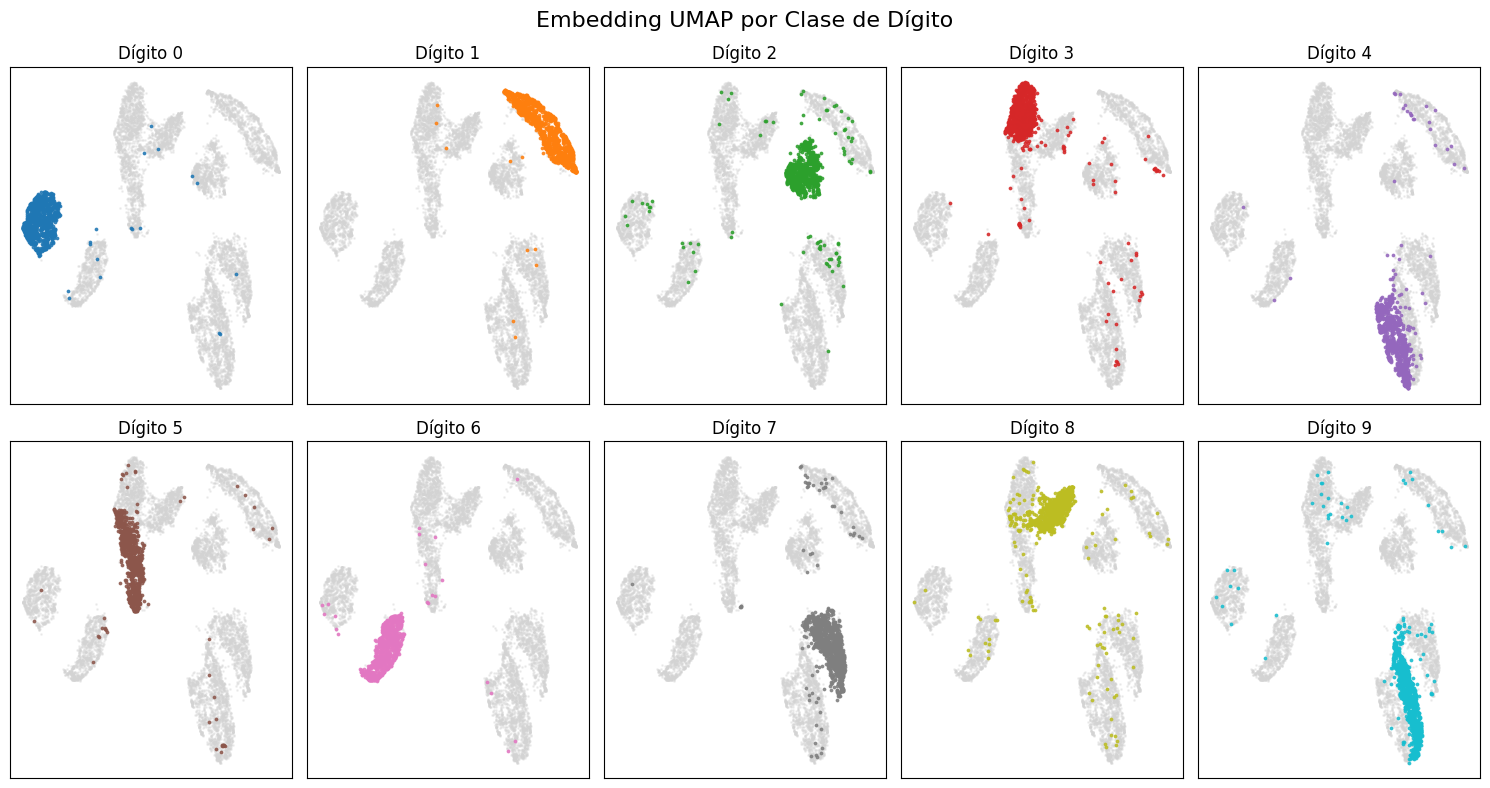

In [ ]:
# Visualización separada por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Embedding UMAP por Clase de Dígito', fontsize=16)

for digit in range(10):
    row = digit // 5
    col = digit % 5

    # Filtrar puntos de la clase actual
    mask = Y_subset == digit

    # Scatter plot de fondo (gris)
    axes[row, col].scatter(
        embedding[:, 0],
        embedding[:, 1],
        c='lightgray',
        s=1,
        alpha=0.3
    )

    # Scatter plot de la clase actual (coloreado)
    axes[row, col].scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=f'C{digit}',
        s=3,
        alpha=0.8
    )

    axes[row, col].set_title(f'Dígito {digit}')
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

## Análisis de Parámetros UMAP

In [ ]:
!pip install colorama
from colorama import Fore

### `n_neighbors` (Vecindarios Locales)

*Conceptualmente:*
- Número de vecinos cercanos considerados para cada punto
- Escala local-global: Balance entre estructura local y global
- Construcción del grafo: Número de conexiones por nodo

*Funcionamiento interno:*

- Construcción del grafo de vecindarios:
```python
# Pseudocódigo del proceso
for punto_i in dataset:
    # Encontrar los k vecinos más cercanos
    vecinos = encontrar_k_vecinos_mas_cercanos(punto_i, k=15)
    
    # Crear aristas con pesos basados en distancias
    for vecino_j in vecinos:
        distancia = calcular_distancia(punto_i, vecino_j)
        peso = funcion_probabilidad(distancia)
        grafo.agregar_arista(punto_i, vecino_j, peso)
```

*Efectos de diferentes valores:*

n_neighbors pequeño (5-10):
- Preserva estructura local: Detalles finos visibles
- Clusters más granulares: Subclusters evidentes
- $\times$ Estructura global fragmentada: Conexiones a larga distancia perdidas
- $\times$ Más ruido: Sensible a variaciones locales

n_neighbors medio (15-30):
- Balance óptimo: Estructura local y global preservadas
- Robustez: Menos sensible a ruido
- Generalización: Captura patrones consistentes
- Recomendación: Valor por defecto para la mayoría de casos

n_neighbors grande (50-200):
- Estructura global clara: Relaciones macro preservadas
- Smooth embeddings: Transiciones suaves entre clusters
- $\times$ Pérdida de detalles locales: Estructuras finas comprimidas
- $\times$ Over-smoothing: Posible fusión de clusters distintos

Analogía:
Imagina que estás en una ciudad desconocida:
- n_neighbors=5: Solo preguntas a los 5 vecinos más cercanos $\to$ conoces tu barrio detalladamente
- n_neighbors=15: Preguntas a 15 personas $\to$ entiendes el barrio y algo de la ciudad
- n_neighbors=50: Preguntas a 50 personas $\to$ tienes mapa general pero pierdes detalles locales

Impacto en MNIST:
```python
# Ejemplo visual del efecto
n_neighbors_values = [5, 15, 50, 100]

# Con n_neighbors=5:  Dígitos similares forman sub-clusters muy separados
# Con n_neighbors=15: Balance óptimo, clusters claros pero conectados
# Con n_neighbors=50: Visión macro, transiciones suaves entre dígitos
```

UMAP con n_neighbors=5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con n_neighbors=15...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con n_neighbors=50...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



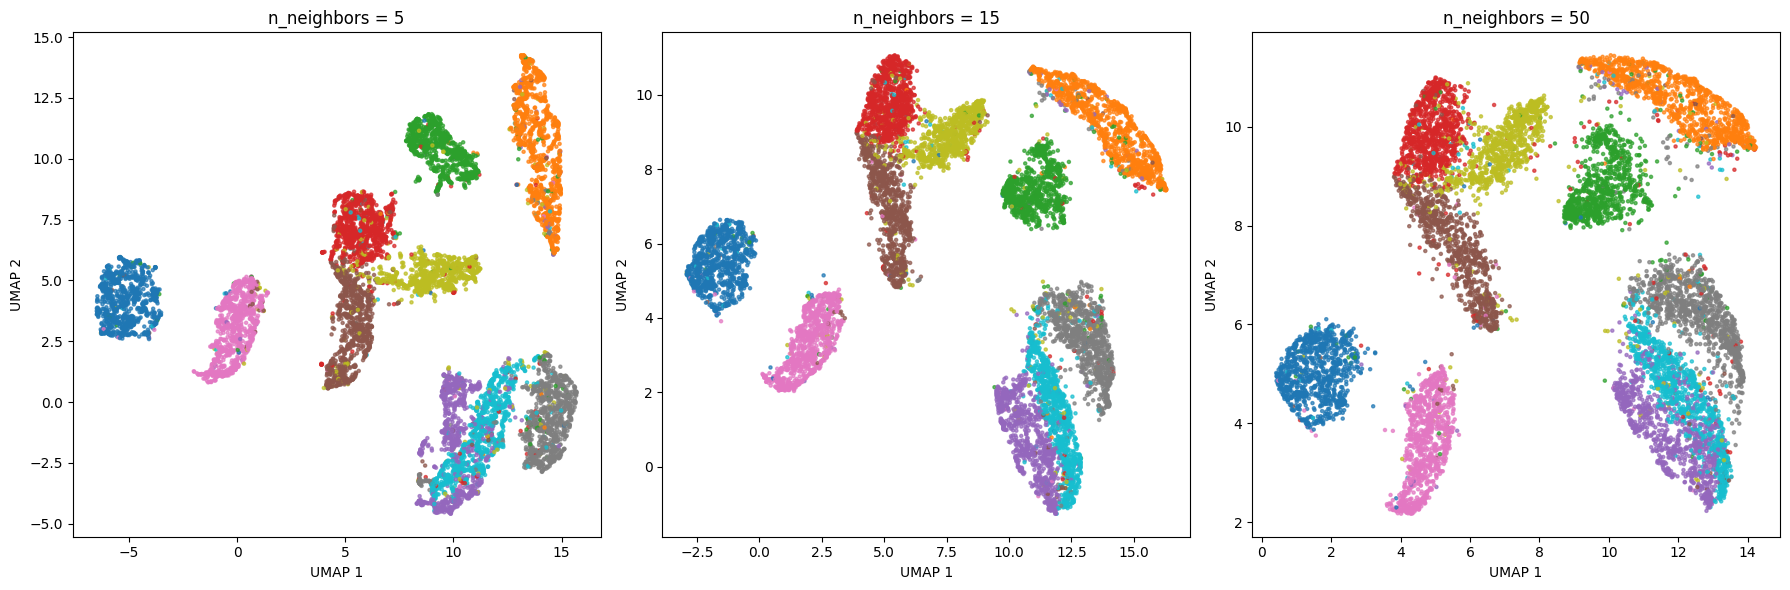

In [ ]:
##### Comparar diferentes valores de n_neighbors #####
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
n_neighbors_values = [5, 15, 50]

for i, n_neighbors in enumerate(n_neighbors_values):
    print(Fore.RED + f"UMAP con n_neighbors={n_neighbors}...")

    reducer_temp = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=0.1,
        random_state=42
    )

    embedding_temp = reducer_temp.fit_transform(X_subset)

    scatter = axes[i].scatter(
        embedding_temp[:, 0],
        embedding_temp[:, 1],
        c=Y_subset,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    axes[i].set_title(f'n_neighbors = {n_neighbors}')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

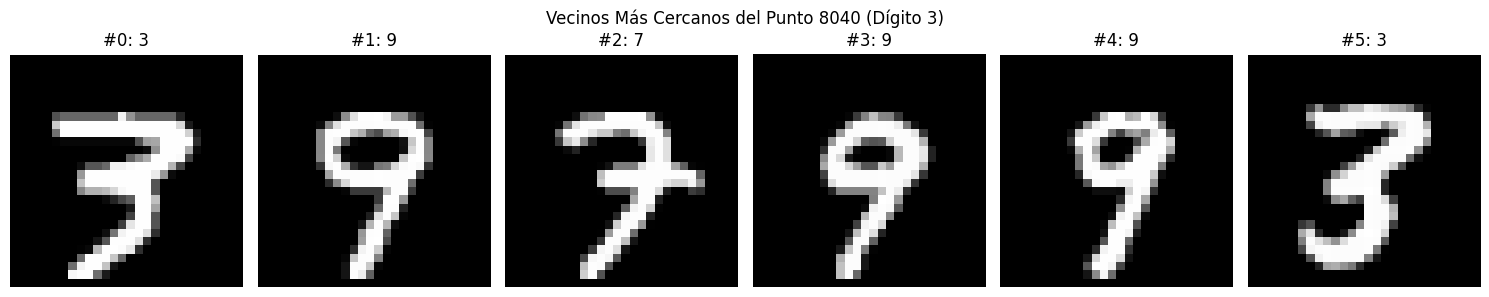

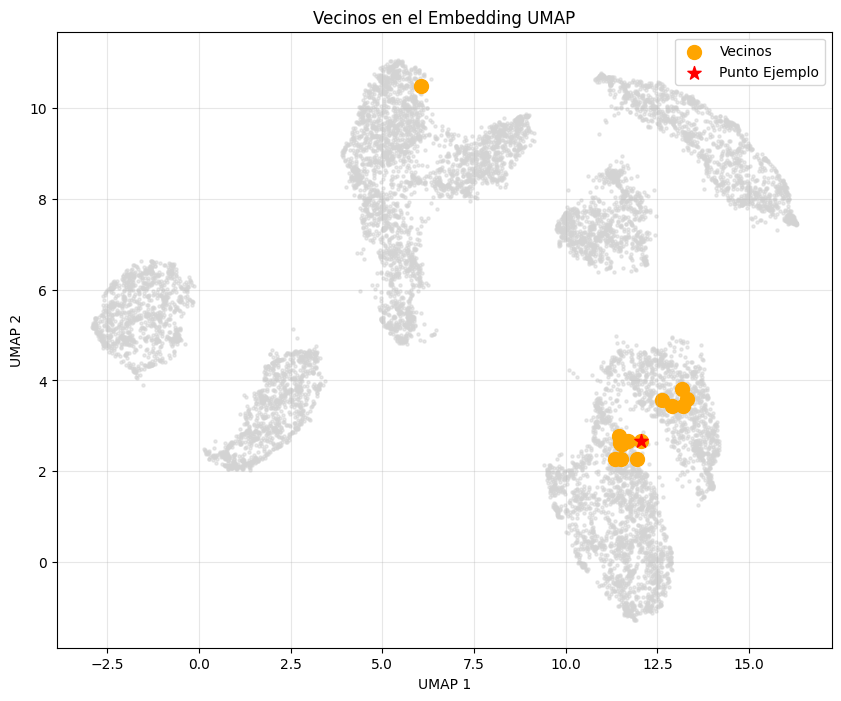

In [ ]:
##### Analizar la estructura de vecindarios #####
from sklearn.neighbors import NearestNeighbors

# Encontrar vecinos más cercanos en el espacio original
nn_original = NearestNeighbors(n_neighbors=15, metric='euclidean')
nn_original.fit(X_subset)

# Seleccionar un punto de ejemplo
example_idx = 8040 # Puedes cambar de punto
distances, indices = nn_original.kneighbors([X_subset[example_idx]])

# Visualizar vecinos en espacio original
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle(f'Vecinos Más Cercanos del Punto {example_idx} (Dígito {Y_subset[example_idx]})')

for i in range(6):
    neighbor_idx = indices[0][i]
    axes[i].imshow(X_subset[neighbor_idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'#{i}: {Y_subset[neighbor_idx]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Mostrar posición en embedding UMAP
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c='lightgray', s=5, alpha=0.5)
plt.scatter(embedding[indices[0], 0], embedding[indices[0], 1],
           c='orange', s=100, marker='o', label='Vecinos')
plt.scatter(embedding[example_idx, 0], embedding[example_idx, 1],
           c='red', s=100, marker='*', label='Punto Ejemplo')
plt.legend()
plt.title('Vecinos en el Embedding UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

### `min_dist` (Distancia Mínima)

*Conceptualmente:*
- Distancia mínima entre puntos en el embedding de baja dimensión
- Compactación vs. dispersión: Qué tan "apretados" están los clusters
- Solo afecta el embedding: No afecta la topología "aprendida"

*Funcionamiento interno:*

```python
# Pseudocódigo simplificado
def optimizar_embedding(grafo, min_dist):
    # Inicializar posiciones aleatorias en 2D
    posiciones = inicializar_aleatoriamente()
    
    for iteracion in range(n_epochs):
        for arista in grafo:
            punto_a, punto_b = arista
            
            # Calcular distancia actual en embedding
            dist_actual = distancia(posiciones[punto_a], posiciones[punto_b])
            
            # Si son vecinos en el grafo:
            if son_vecinos(punto_a, punto_b):
                # Fuerza atractiva (quiere acercarlos)
                if dist_actual > min_dist:
                    aplicar_fuerza_atractiva()
            else:
                # Fuerza repulsiva (quiere alejarlos)
                if dist_actual < dist_minima_no_vecinos:
                    aplicar_fuerza_repulsiva()
```

*Efectos de diferentes valores:*

min_dist pequeño (0.0 - 0.1):
- Clusters compactos**: Puntos muy juntos dentro de clusters
- Separación clara: Clusters bien diferenciados
- Visualización nítida: Estructuras más definidas
- $\times$ Posible solapamiento interno: Detalles internos comprimidos

min_dist medio (0.1 - 0.5):
- Balance visual: Ni muy compacto ni muy disperso
- Estructura interna visible: Detalles dentro de clusters preservados
- Recomendación: Valor estándar por defecto

min_dist grande (0.5 - 1.0):**
- Distribución uniforme: Puntos más espaciados
- Topología global clara: Relaciones macro visibles
- $\times$ Clusters difusos: Límites menos definidos
- $\times$ Uso ineficiente del espacio: Visualización más grande de lo necesario

Analogía:
Imagina organizar personas en una sala:
- min_dist=0.0: Personas del mismo grupo pegadas hombro con hombro
- min_dist=0.1: Espacio personal cómodo dentro de grupos
- min_dist=0.5: Cada persona tiene bastante espacio alrededor

Resumen:
```
┌───────────────────────────────────────────────────┐
│  n_neighbors: "¿Con quién debo agruparme?"        │
│  min_dist:    "¿Qué tan cerca debo estar?"        │
└───────────────────────────────────────────────────┘
```

Impacto en MNIST:
```python
min_dist=0.0:  #Clusters muy densos, como "islas" compactas
min_dist=0.1:  #Clusters definidos con estructura interna visible
min_dist=0.5:  #Clusters más difusos, transiciones suaves
```

UMAP con min_dist=0.0...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con min_dist=0.5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



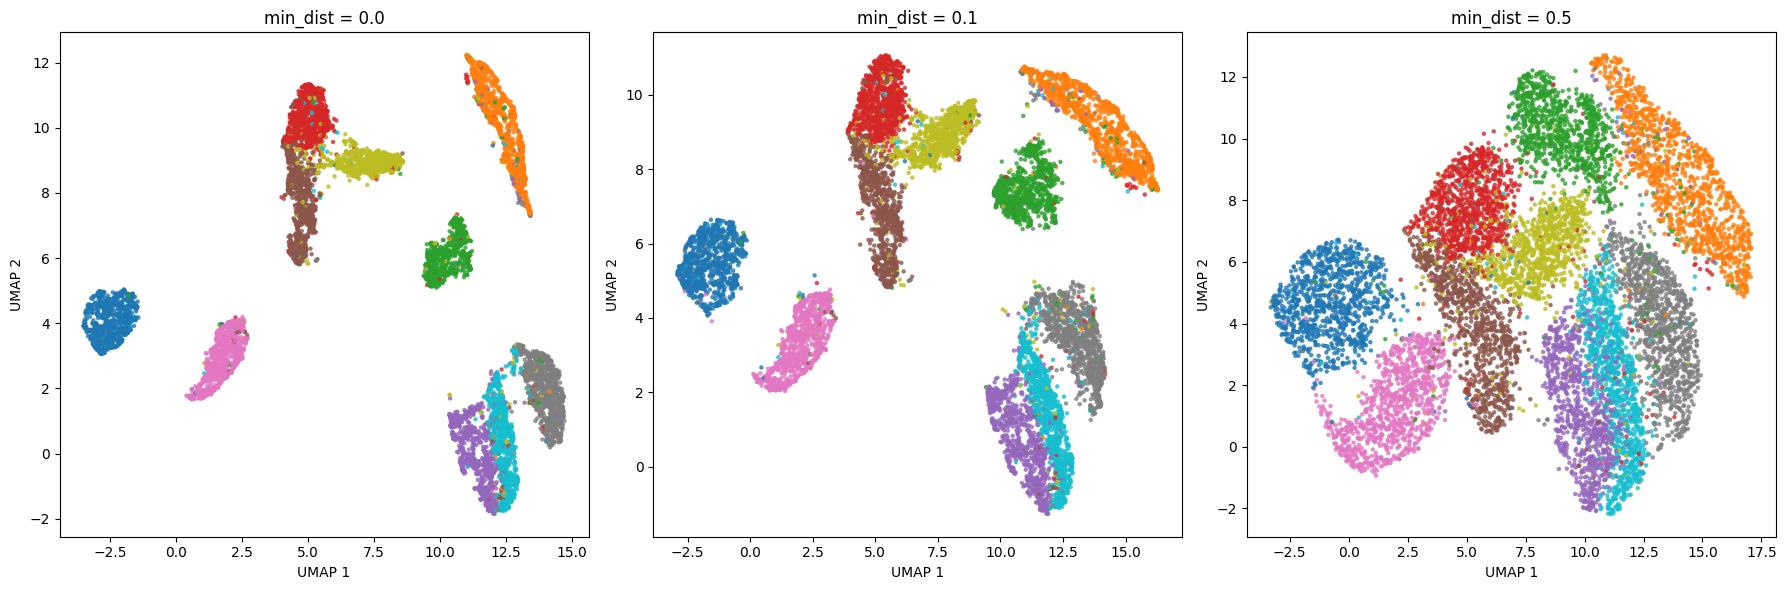

In [ ]:
##### Comparar diferentes valores de min_dist #####
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
min_dist_values = [0.0, 0.1, 0.5]

for i, min_dist in enumerate(min_dist_values):
    print(Fore.RED + f"UMAP con min_dist={min_dist}...")

    reducer_temp = umap.UMAP(
        n_neighbors=15,
        min_dist=min_dist,
        random_state=42
    )

    embedding_temp = reducer_temp.fit_transform(X_subset)

    scatter = axes[i].scatter(
        embedding_temp[:, 0],
        embedding_temp[:, 1],
        c=Y_subset,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    axes[i].set_title(f'min_dist = {min_dist}')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

### `n_components` (Dimensionalidad de Salida)

*Definición:*
- Número de dimensiones en el espacio de embedding
- Reducción: 784 dimensiones $\to$ 2 dimensiones

*Opciones comunes:*

n_components=2:
- Visualización directa: Gráficas 2D fáciles de interpretar
- Exploración rápida: Scatter plots inmediatos
- $\times$ Pérdida de información: Mayor compresión
- Usos comunes: Análisis exploratorio, presentaciones, papers

n_components=3:
- Más información preservada: Menos compresión
- Visualización 3D: Gráficas rotables
- $\times$ Más complejo visualizar: Requiere herramientas 3D
- Tip: Cuando 2D no es suficientemente informativo

n_components=10-50:
- Máxima preservación: Estructura compleja preservada
- Preprocessing para ML: Input para clasificadores
- $\times$ No visualizable directamente: Requiere análisis adicional
- Usos comunes: Feature engineering, pipeline de ML

*Comparación cuantitativa:*
```python
# Información preservada (aproximado para MNIST)
n_components=2:   #~65% de varianza explicada
n_components=3:   #~75% de varianza explicada
n_components=10:  #~90% de varianza explicada
n_components=50:  #~98% de varianza explicada
```

*Consideraciones prácticas:*
```python
# Para visualización
n_components = 2  # Siempre la primera opción

# Para preprocessing de ML
n_components = min(50, n_samples // 10)  # "Regla de oro"

# Para análisis detallado
n_components = 3  # Permite visualización 3D interactiva
```

UMAP con n_components=2...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con n_components=3...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP con n_components=50...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



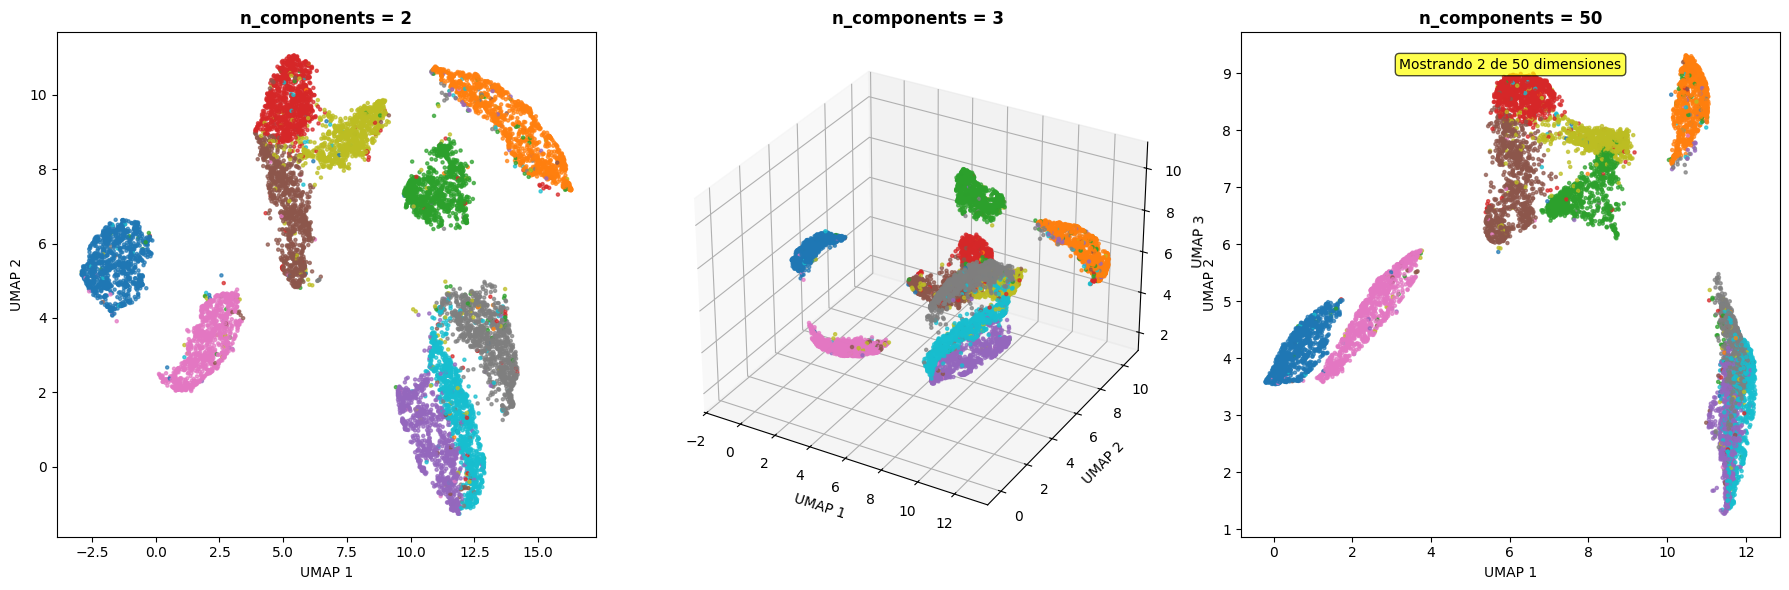

In [ ]:
##### Comparar diferentes valores de n_components #####

n_components_values = [2, 3, min(50, n_samples // 10)]
fig = plt.figure(figsize=(18, 6))

for i, n_comp in enumerate(n_components_values):
    print(Fore.RED + f"UMAP con n_components={n_comp}...")

    reducer_temp = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=n_comp,  # Este es el parámetro que estamos variando
        random_state=42
    )

    embedding_temp = reducer_temp.fit_transform(X_subset)

    if n_comp == 2:
        # Para 2D: scatter plot normal
        ax = fig.add_subplot(1, 3, i+1)
        scatter = ax.scatter(
            embedding_temp[:, 0],
            embedding_temp[:, 1],
            c=Y_subset,
            cmap='tab10',
            s=5,
            alpha=0.7
        )
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')

    elif n_comp == 3:
        # Para 3D: scatter plot 3D
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        scatter = ax.scatter(
            embedding_temp[:, 0],
            embedding_temp[:, 1],
            embedding_temp[:, 2],
            c=Y_subset,
            cmap='tab10',
            s=5,
            alpha=0.7
        )
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.set_zlabel('UMAP 3')

    else:
        # Para dimensiones altas: mostrar primeras 2 componentes
        ax = fig.add_subplot(1, 3, i+1)
        scatter = ax.scatter(
            embedding_temp[:, 0],
            embedding_temp[:, 1],
            c=Y_subset,
            cmap='tab10',
            s=5,
            alpha=0.7
        )
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.text(0.5, 0.95, f'Mostrando 2 de {n_comp} dimensiones',
                ha='center', va='top', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    ax.set_title(f'n_components = {n_comp}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusiones

In [ ]:
##### Calcular métricas de calidad del embedding #####
from sklearn.metrics import silhouette_score

# Silhouette Score
sil_score = silhouette_score(embedding, Y_subset)
print(f"Silhouette Score: {sil_score:.3f}")

# Preservación de vecindarios locales
def local_neighborhood_preservation(X_original, X_embedded, k=10):
    """Calcula qué tan bien se preservan los vecindarios locales"""

    # Vecinos en espacio original
    nn_orig = NearestNeighbors(n_neighbors=k+1)
    nn_orig.fit(X_original)
    _, neighbors_orig = nn_orig.kneighbors(X_original)

    # Vecinos en espacio embedido
    nn_emb = NearestNeighbors(n_neighbors=k+1)
    nn_emb.fit(X_embedded)
    _, neighbors_emb = nn_emb.kneighbors(X_embedded)

    # Calcular preservación promedio
    preservation_scores = []
    for i in range(len(X_original)):
        orig_neighbors = set(neighbors_orig[i][1:])  # Excluir el punto mismo
        emb_neighbors = set(neighbors_emb[i][1:])

        intersection = len(orig_neighbors.intersection(emb_neighbors))
        preservation = intersection / k
        preservation_scores.append(preservation)

    return np.mean(preservation_scores)

# Calcular preservación de vecindarios
preservation = local_neighborhood_preservation(X_subset, embedding, k=10)
print(f"Preservación de Vecindarios Locales: {preservation:.3f}")

Silhouette Score: 0.390
Preservación de Vecindarios Locales: 0.243


In [ ]:
# Resumen de resultados
print("\n" + "="*50)
print("RESUMEN DE UMAP EN MNIST")
print("="*50)
print(f"Muestras analizadas: {n_samples}")
print(f"Dimensión original: {X_subset.shape[1]}")
print(f"Dimensión final: {embedding.shape[1]}")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Preservación Local: {preservation:.3f}")
print("="*50)


RESUMEN DE UMAP EN MNIST
Muestras analizadas: 10000
Dimensión original: 784
Dimensión final: 2
Silhouette Score: 0.390
Preservación Local: 0.243
